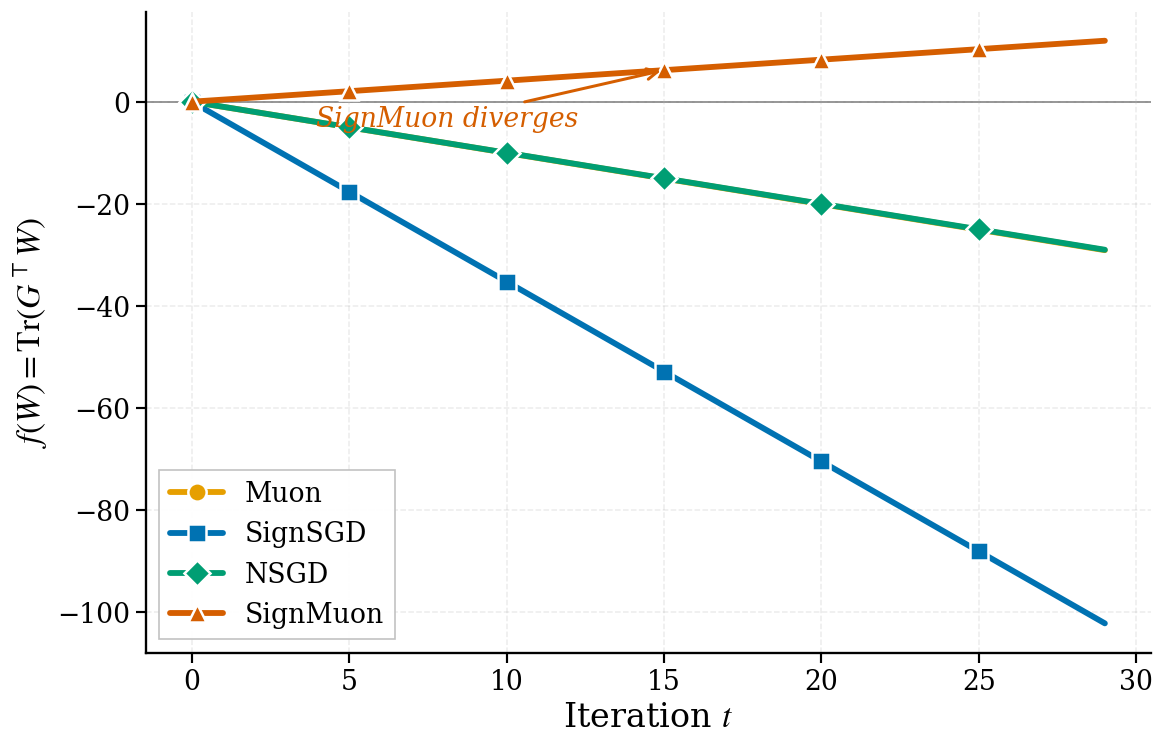

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Publication-ready plotting style (NeurIPS / ICML / AAAI)
# Run once; subsequent figures inherit it.
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 1.4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.9,
    "lines.linewidth": 3.5,
    "lines.markersize": 11,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.edgecolor": "0.75",
    "legend.fancybox": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ==========================================
# 1. Counterexample matrices (Theorem 1)
# ==========================================
O = (1 / 103) * np.array([
    [ 101,  20,   2,  -2],
    [ -20,  97,  20, -20],
    [  -2,  20,   2, 101],
    [  -2,  20,-101,  -2]
])
u1 = (1 / np.sqrt(309)) * np.array([10, -3, 10, 10]).reshape(-1, 1)
v1 = (1 / np.sqrt(309)) * np.array([10,  3,-10, 10]).reshape(-1, 1)
G = 1000 * (u1 @ v1.T) + O

# ==========================================
# 2. Optimizer directions on the constant gradient G
# ==========================================
def nsgd_update(g):
    return g / np.linalg.norm(g)

def sign_sgd_update(g):
    return np.sign(g)

def muon_update(g):
    U, _, Vt = np.linalg.svd(g, full_matrices=False)
    return U @ Vt

def sign_muon_update(g):
    U, _, Vt = np.linalg.svd(g, full_matrices=False)
    return np.sign(U @ Vt)

optimizers = {
    "NSGD":     nsgd_update,
    "SignSGD":  sign_sgd_update,
    "Muon":     muon_update,
    "SignMuon": sign_muon_update,
}

# ==========================================
# 3. Run the deterministic loop  W_{t+1} = W_t - lr * d(G)
# ==========================================
T, lr = 30, 1e-3
func_vals = {name: [] for name in optimizers}
for name, fn in optimizers.items():
    W = np.zeros((4, 4))
    for t in range(T):
        func_vals[name].append(np.sum(G * W))   # f(W) = Tr(G^T W)
        W = W - lr * fn(G)

# ==========================================
# 4. Figure (SignMuon diverges, the rest descend)
# ==========================================
styles = {  # name: (color, marker)
    "Muon":     ("#E69F00", "o"),
    "SignSGD":  ("#0072B2", "s"),
    "NSGD":     ("#009E73", "D"),
    "SignMuon": ("#D55E00", "^"),
}

fig, ax = plt.subplots(figsize=(10, 6.5))
for name, (color, marker) in styles.items():
    ax.plot(func_vals[name], label=name, color=color, linestyle="-",
            linewidth=3.5, marker=marker, markersize=11, markerfacecolor=color,
            markeredgecolor="white", markeredgewidth=1.5, markevery=5,
            solid_capstyle="round", zorder=3)

ax.set_xlabel(r"Iteration $t$", fontsize=20)
ax.set_ylabel(r"$f(W) = \mathrm{Tr}(G^\top W)$", fontsize=20)
ax.axhline(0, color="black", linewidth=1.0, linestyle="-", alpha=0.5, zorder=1)
ax.tick_params(axis="both", labelsize=16, length=6, width=1.3)
ax.grid(True, linestyle="--", linewidth=0.9, alpha=0.25, zorder=0)

# arrow kept on the first figure
div_step = 15
ax.annotate("SignMuon diverges",
            xy=(div_step, func_vals["SignMuon"][div_step]),
            xytext=(0.30, 0.82), textcoords="axes fraction",
            color="#D55E00", fontstyle="italic", ha="center", fontsize=16,
            arrowprops=dict(arrowstyle="->", color="#D55E00", lw=1.8))

ax.legend(loc="lower left", fontsize=16, frameon=True, framealpha=0.95, edgecolor="0.75")
fig.tight_layout()
plt.show()

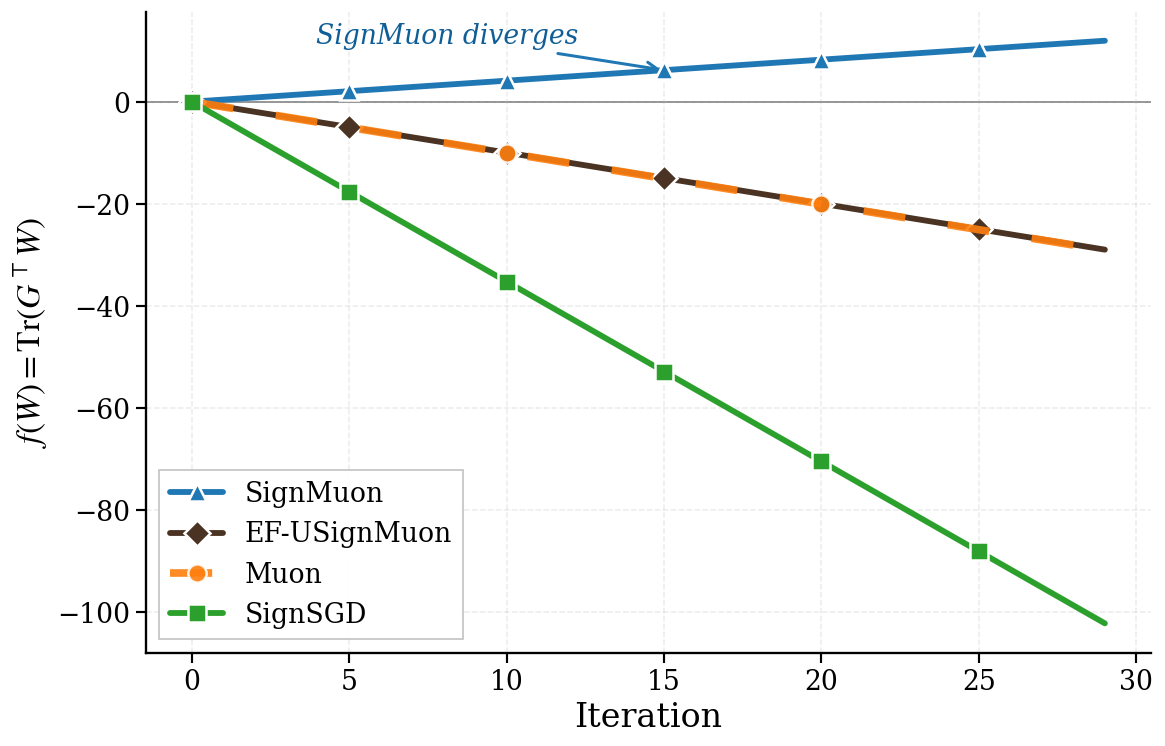

In [8]:
# Same experiment as the first figure, but with NSGD replaced by EF-USignMuon
# (1-way / uplink EF21 + server-side Muon LMO). SignMuon diverges, while
# EF-USignMuon converges together with Muon and SignSGD.
import numpy as np
import matplotlib.pyplot as plt

# --- counterexample matrices (same as the first cell) ---
O = (1 / 103) * np.array([
    [ 101,  20,   2,  -2],
    [ -20,  97,  20, -20],
    [  -2,  20,   2, 101],
    [  -2,  20,-101,  -2]
])
u1 = (1 / np.sqrt(309)) * np.array([10, -3, 10, 10]).reshape(-1, 1)
v1 = (1 / np.sqrt(309)) * np.array([10,  3,-10, 10]).reshape(-1, 1)
G = 1000 * (u1 @ v1.T) + O

# --- optimizer directions ---
def sign_sgd_update(g):
    return np.sign(g)

def muon_update(g):
    U, _, Vt = np.linalg.svd(g, full_matrices=False)
    return U @ Vt

def sign_muon_update(g):
    U, _, Vt = np.linalg.svd(g, full_matrices=False)
    return np.sign(U @ Vt)

def make_ef_signmuon():
    """1-Way (uplink) EF-USignMuon: EF21 estimator + server-side Muon LMO."""
    state = {"g": np.zeros((4, 4))}
    def update(g):
        delta = g - state["g"]
        state["g"] = state["g"] + np.mean(np.abs(delta)) * np.sign(delta)
        U, _, Vt = np.linalg.svd(state["g"], full_matrices=False)
        return U @ Vt
    return update

optimizers = {
    "EF-USignMuon": make_ef_signmuon(),
    "SignSGD":     sign_sgd_update,
    "Muon":        muon_update,
    "SignMuon":    sign_muon_update,
}

# --- run the deterministic loop ---
T, lr = 30, 1e-3
func_vals = {name: [] for name in optimizers}
for name, fn in optimizers.items():
    W = np.zeros((4, 4))
    for t in range(T):
        func_vals[name].append(np.sum(G * W))
        W = W - lr * fn(G)

# --- figure (SignMuon diverges, EF-USignMuon / Muon / SignSGD descend) ---
styles = {
    "SignMuon":    ("#1f77b4", "^"),
    "EF-USignMuon": ("#4A3322", "D"),
    "Muon":        ("#ff7f0e", "o"),
    "SignSGD":     ("#2ca02c", "s"),
}

fig, ax = plt.subplots(figsize=(10, 6.5))
for name, (color, marker) in styles.items():
    if name == "Muon":
        ax.plot(func_vals[name], label=name, color=color, linestyle= (0, (5.5, 5.6)), alpha=0.9,
            linewidth=4.6, marker=marker, markersize=11, markerfacecolor=color,
            markeredgecolor="white", markeredgewidth=1.5, markevery=10, 
            solid_capstyle="round", zorder=3)
    else:
        ax.plot(func_vals[name], label=name, color=color, linestyle="-",
                linewidth=3.5, marker=marker, markersize=11, markerfacecolor=color,
                markeredgecolor="white", markeredgewidth=1.5, markevery=5,
                solid_capstyle="round", zorder=3)

ax.set_xlabel(r"Iteration", fontsize=20)
ax.set_ylabel(r"$f(W) = \mathrm{Tr}(G^\top W)$", fontsize=20)
ax.axhline(0, color="black", linewidth=1.0, linestyle="-", alpha=0.5, zorder=1)
ax.tick_params(axis="both", labelsize=16, length=6, width=1.3)
ax.grid(True, linestyle="--", linewidth=0.9, alpha=0.25, zorder=0)

div_step = 15
ax.annotate("SignMuon diverges",
            xy=(div_step, func_vals["SignMuon"][div_step]),
            xytext=(0.30, 0.95), textcoords="axes fraction",
            color="#0f5e97", fontstyle="italic", ha="center", fontsize=16,
            arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=1.8))

ax.legend(loc="lower left", fontsize=16, frameon=True, framealpha=0.95, edgecolor="0.75")
fig.tight_layout()
plt.savefig("im_dif/signmuon_divergence_ef.pdf", bbox_inches="tight")
plt.savefig("im_dif/signmuon_divergence_ef.png", bbox_inches="tight")
plt.show()

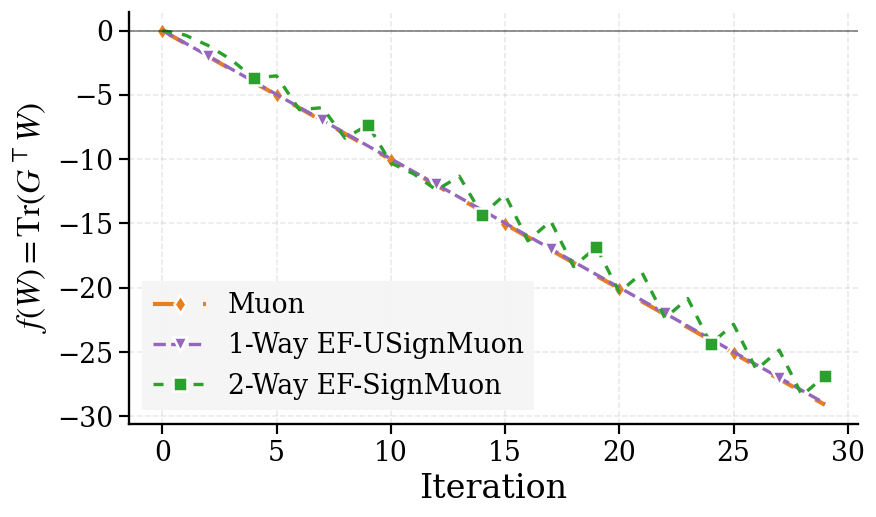

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1 & 2. Styling and Matrices (Same as before)
# ==========================================
plt.rcParams.update({'font.size': 13, 'font.family': 'serif', 'axes.grid': True, 'grid.alpha': 0.3})

O = (1/103) * np.array([
    [ 101,  20,   2,  -2],
    [ -20,  97,  20, -20],
    [  -2,  20,   2, 101],
    [  -2,  20,-101,  -2]
])
u1 = (1 / np.sqrt(309)) * np.array([10, -3, 10, 10]).reshape(-1, 1)
v1 = (1 / np.sqrt(309)) * np.array([10,  3,-10, 10]).reshape(-1, 1)
G = 1000 * (u1 @ v1.T) + O

# ==========================================
# 3. Define Optimizers
# ==========================================
def get_muon():
    def update(g):
        U, _, Vt = np.linalg.svd(g, full_matrices=False)
        return U @ Vt
    return update

def get_ef_signmuon():
    """1-Way (Uplink) EF-USignMuon"""
    state = {'g': np.zeros((4, 4))}
    def update(G):
        delta = G - state['g']
        s = np.sign(delta) * np.mean(np.abs(delta))
        state['g'] = state['g'] + s

        U, _, Vt = np.linalg.svd(state['g'], full_matrices=False)
        return U @ Vt
    return update

def get_bidirectional_ef_signmuon(lr=1e-3):
    """
    2-Way (Bidirectional) EF-USignMuon mapping to Algorithm 1.
    Compresses both the gradient (uplink) and the model update (downlink).
    """
    state = {
        'g': np.zeros((4, 4)),  # Server's gradient estimator
        'X': np.zeros((4, 4)),  # Server's true (uncompressed) model
        'W': np.zeros((4, 4))   # Synchronized model shift
    }

    def update(G_client):
        # --- UPLINK (Client to Server) ---
        # 1. Compress gradient residual
        delta_g = G_client - state['g']
        R = np.sign(delta_g) * np.mean(np.abs(delta_g))

        # 2. Server updates gradient estimator
        state['g'] = state['g'] + R

        # --- SERVER UPDATE ---
        # 3. Server computes true LMO (Muon) step using estimator
        U, _, Vt = np.linalg.svd(state['g'], full_matrices=False)
        LMO_step = U @ Vt

        # 4. Server updates its underlying full-precision model
        state['X'] = state['X'] - lr * LMO_step

        # --- DOWNLINK (Server to Client) ---
        # 5. Server compresses the model residual (EF21-P mechanism)
        delta_W = state['X'] - state['W']
        S = np.sign(delta_W) * np.mean(np.abs(delta_W))

        # 6. Both Server and Client update the synchronized model W
        state['W'] = state['W'] + S

        # Because the outer loop is `W = W - lr * return_value`,
        # we return `-S / lr` so the client mathematically executes `W = W + S`.
        return -S / lr

    return update

optimizers = {
    "Muon": (get_muon, 1e-3),
    "1-Way EF-USignMuon": (get_ef_signmuon, 1e-3),
    "2-Way EF-SignMuon": (get_bidirectional_ef_signmuon, 1e-3)
}

# ==========================================
# 4. Run Optimization Loop
# ==========================================
T = 30
func_vals = {name: [] for name in optimizers}

for name, (update_factory, lr) in optimizers.items():
    W = np.zeros((4, 4))

    # Pass lr to the bidirectional factory so it can simulate the server tracking X
    update_fn = update_factory(lr) if '2-Way' in name else update_factory()

    for t in range(T):
        func_vals[name].append(np.sum(G * W))
        W = W - lr * update_fn(G)

# ==========================================
# 5. Generate the Plot
# ==========================================
fig, ax = plt.subplots(figsize=(7.5, 4.5))

styles = {
    "Muon":              {"color": "#e67e22", "marker": "d", "linestyle": (0, (6, 6)), "linewidth": 2.5, "markevery": (0, 5)},
    "1-Way EF-USignMuon": {"color": "#9467bd", "marker": "v", "linestyle": "--",        "linewidth": 2.0, "markevery": (2, 5)},
    "2-Way EF-SignMuon": {"color": "#2ca02c", "marker": "s", "linestyle": (0, (3, 3)), "linewidth": 2.0, "markevery": (4, 5)}
}

for name, f_curve in func_vals.items():
    ax.plot(f_curve, label=name, **styles[name], markersize=8, markeredgecolor='white', markeredgewidth=1.5)

ax.set_xlabel(r"Iteration")
ax.set_ylabel(r"$f(W) = \mathrm{Tr}(G^\top W)$")
ax.axhline(0, color='black', linewidth=1.2, linestyle='-', alpha=0.4)
ax.legend(loc='lower left', frameon=True, edgecolor='none', facecolor='whitesmoke')

plt.tight_layout()
# plt.savefig("signmuon_ef_2_versions.pdf", bbox_inches="tight")
# plt.savefig("signmuon_ef_2_versions.png", bbox_inches="tight")
plt.show()